In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [13]:
# Carregar dataSet
df = pd.read_csv('acessos_sistema.csv')
print(df.head())
print(df.info())

   hora_acesso  duracao_sessao_min  numero_tentativas_login  \
0            9                  35                        1   
1           10                  40                        1   
2           11                  25                        1   
3           14                  50                        1   
4           15                  45                        1   

   ip_diferente_habitual  quantidade_paginas_acessadas  
0                      0                            12  
1                      0                            15  
2                      0                             9  
3                      0                            18  
4                      0                            16  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   hora_acesso                   80 non-null     int64
 1   d

In [14]:
# Selecionar as variaveis de interesse
colunas = ["hora_acesso", "duracao_sessao_min", "numero_tentativas_login", "ip_diferente_habitual", "quantidade_paginas_acessadas"]
x = df[colunas]

# Padronizar os dados
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [15]:
# Treinamento
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(x_scaled)

IsolationForest(contamination=0.1, random_state=42)

In [16]:
# Predição das anomalias
# -1 = anomalia | 1 = normal

df["anomaly"] = model.predict(x_scaled)

# Score da anomalia (Quanto menor, mais anomolo ele é)
df["score"] = model.decision_function(x_scaled)

# Converter para rótulo legível
df["legenda"] = df["anomaly"].map({1: "normal", -1: "anomalia"})


In [17]:
# Registros
df

,hora_acesso,duracao_sessao_min,numero_tentativas_login,ip_diferente_habitual,quantidade_paginas_acessadas,anomaly,score,legenda
0,9,35,1,0,12,1,0.097975,normal
1,10,40,1,0,15,1,0.129330,normal
2,11,25,1,0,9,1,0.123665,normal
3,14,50,1,0,18,1,0.143650,normal
4,15,45,1,0,16,1,0.123135,normal
...,...,...,...,...,...,...,...,...
75,3,240,1,1,110,-1,-0.023733,anomalia
76,1,2,9,1,1,1,0.115795,normal
77,22,200,1,1,85,1,0.007313,normal
78,23,3,10,1,2,1,0.000007,normal


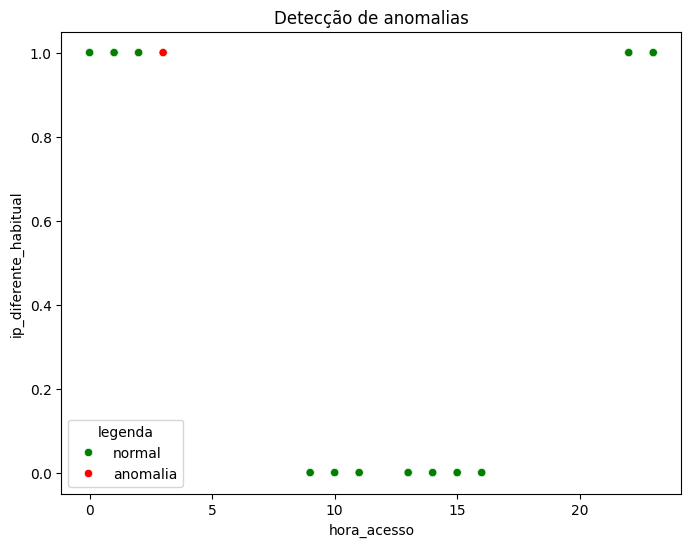

In [18]:
# Visualização em gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="hora_acesso",
    y="ip_diferente_habitual",
    hue="legenda",
    palette=["green", "red"]
)

plt.title("Detecção de anomalias")
plt.show()

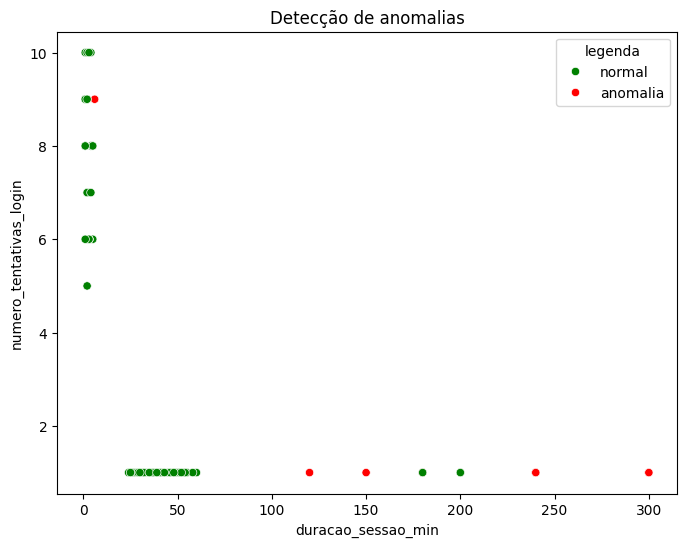

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="duracao_sessao_min",
    y="numero_tentativas_login",
    hue="legenda",
    palette=["green", "red"]
)

plt.title("Detecção de anomalias")
plt.show()

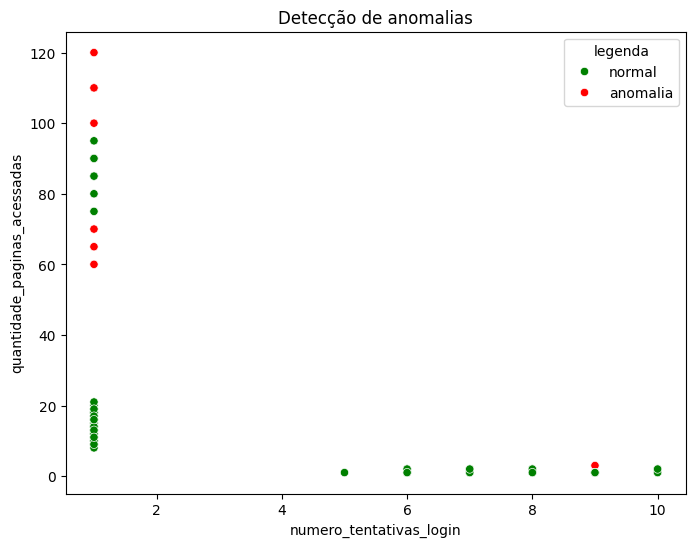

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="numero_tentativas_login",
    y="quantidade_paginas_acessadas",
    hue="legenda",
    palette=["green", "red"]
)

plt.title("Detecção de anomalias")
plt.show()